<a href="https://colab.research.google.com/github/felipebrsm/PUC_Sprint_1_ML-FBRSM/blob/main/notebook/MVP_FBRSM_PUC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#MVP: *Machine Learning & Analytics*

Modelo de Classificação de Dados Geotécnicos por *Random Forest* e *K-Means*

**Autor:** Felipe Barreto R. S. Macedo

**Data:** 05/07/2026

**Matrícula:** XXXXX

**Dataset:** Ex: Global Dataset of Cone Penetration Test Results - Jianye Ching (http://140.112.12.21/issmge/Database/Global_CPT_3_1196/Global_CPT_3_1196.zip)


---



## ✅ Checklist do MVP (o que precisa conter)
- [ ] **Problema definido** e contexto de negócio
- [ ] **Carga e preparação** dos dados (sem vazamento de dados)
- [ ] **Divisão** em treino/validação/teste (ou validação cruzada apropriada)
- [ ] **Tratamento**: limpeza, transformação e **engenharia de atributos**
- [ ] **Modelagem**: comparar abordagens/modelos (com **baseline**)
- [ ] **Otimização de hiperparâmetros**
- [ ] **Avaliação** com **métricas adequadas** e discussão de limitações
- [ ] **Boas práticas**: seeds fixas, tempo de treino, recursos computacionais, documentação
- [ ] **Pipelines reprodutíveis** (sempre que possível)



## 1. Escopo, objetivo e definição do problema

A classificação de tipos de solo é de fundamental importância para a Engenharia Geotécnica, sendo o ensaio de Penetração de Cone Piezométrico (CPT) uma das formas mais confiáveis de obtenção de dados subterrâneos, em particular para projetos submarinos.

O resultado do CPT fornece parâmetros que permitem avaliar granulometria do solo e calcular valores de resistência ao cisalhamento. Usualmente, é utilizado o método empírico de Robertson para classificação de solos (Soil Behavior Type), embora esse modelo seja generalista, muitas vezes não permitindo a avaliação de mudanças de comportamento local.

A proposta desse MVP é a criação de modelos que permitam:
- classificar camadas de solo a partir dos parâmetros do CPT;
- detecte interfaces em camadas;
- comparar com o modelo de Robertson, avaliando concordâncias, discordâncias e abrangência.

Para tanto, foi utilizado um dataset de resultados globais de CPT disponibilizado na internet. Os dados estão divididos por locação, organizados em planilhas .xlsx, e apresentam os parâmetros usuais de resultados de CPT:
- depth - Profundidade (m)
- qc - Resistência de ponta (MPa)
- fs - Atrito lateral (kPa)
- u2 - Poropressão (kPa)

Foram previstas as seguintes etapas:
1. Pré-processamento com compilação, padronização e normalização dos dados.
2. *Feature Engineering* com cálculo das tensões in-situ e dos índices normalizados.
3. Classificação supervisionada pelo modelo de Robertson (parâmetro Ic), servindo de base para a comparação dos modelos.
4. Modelagem não supervisionada por K-Means, com escolha de k por meio do Silhouette Score e método do cotovelo.
5. Modelagem por Random Forest supervisionada pelo método de Robertson, possibilitando predição e indicando a importância de cada feature.
6. Comparação entre K-Means, Random Forest e Robertson.

Como resultado, proponho um log CPT classificado para furos de teste, acompanhado de uma tabela de métricas comparando os dois modelos com Robertson — permitindo avaliar quantitativamente o quanto a classificação automática converge ou diverge do método tradicional.





## 2. Reprodutibilidade e ambiente
Especifique o ambiente. Por exemplo:
- Bibliotecas usadas.
- Seeds fixas para reprodutibilidade.

In [50]:
# ---- CÓDIGO REAL ----------#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, adjusted_rand_score, silhouette_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.



### 2.1 Dependências (opcional)
Instale pacotes extras se necessário. **Mantenha o projeto enxuto** para facilitar a correção.


2.1.a Instalações

In [51]:
!pip install -q imbalanced-learn shap scipy


2.1.a Bibliotecas

In [52]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.optimize import linear_sum_assignment

# Sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    GroupShuffleSplit, GroupKFold, cross_validate
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    cohen_kappa_score, f1_score, accuracy_score,
    silhouette_score, adjusted_rand_score,
    normalized_mutual_info_score, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

# Imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# SHAP
import shap

# Utilitários
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
SEED = 42
np.random.seed(SEED)

print("✅ Imports concluídos com sucesso.")



✅ Imports concluídos com sucesso.



## 3. Dados: carga, entendimento e qualidade
**TODO:** descreva a origem dos dados, dicionário de variáveis e licença/ética quando aplicável.  
Evite **vazamento de dados**. Se usar feature store ou dados sintéticos, explique.


INCLUIR TEXTO EXPLICANDO PROCESSAMENTO

Leitura do Database

In [53]:

# Configuração — altere aqui se o repositório ou caminho do arquivo mudar
USUARIO = 'felipebrsm'
REPO    = 'PUC_Sprint_1_ML-FBRSM'
BRANCH  = 'main'
ARQUIVO = 'data/processed/dataset_compilado.csv'

URL = f'https://raw.githubusercontent.com/{USUARIO}/{REPO}/{BRANCH}/{ARQUIVO}'

df_raw = pd.read_csv(URL)

# borehole_id identifica o furo de forma única: combinação de
# locacao + ensaio (cada ensaio dentro de uma locacao é um furo distinto).
# Isso substitui o borehole_id sintético — GroupShuffleSplit/GroupKFold
# usam esta coluna para garantir que furos inteiros fiquem só em
# treino OU só em teste, nunca nos dois.
df_raw['borehole_id'] = df_raw['locacao'].astype(str) + '_' + df_raw['ensaio'].astype(str)

# Nota: zone_robertson_true (gabarito sintético) NÃO existe em dados
# reais — não há um "rótulo verdadeiro" independente para comparar.
# O único rótulo disponível é zone_robertson, calculado a partir de Ic
# (ver Célula 5) — ele funciona como baseline determinístico, não como
# verdade absoluta. Todas as comparações com zone_robertson_true foram
# removidas das células seguintes por esse motivo.

print(f"📊 Dataset carregado: {df_raw.shape[0]:,} leituras, "
      f"{df_raw['borehole_id'].nunique()} furos")
print(f"   Profundidade máxima média: {df_raw.groupby('borehole_id')['depth'].max().mean():.1f} m")



📊 Dataset carregado: 475,083 leituras, 412 furos
   Profundidade máxima média: 15.0 m


Resumo do Dataset

In [54]:

dataset = df

print('=' * 50)
print('RESUMO DO DATASET COMPILADO')
print('=' * 50)
print(f'Linhas totais  : {len(dataset):,}')
print(f'Locações       : {dataset["locacao"].nunique()}')
print(f'Ensaios únicos : {dataset[["locacao","ensaio"]].drop_duplicates().shape[0]}')
print(f'Abas únicas    : {dataset[["locacao","ensaio","pagina"]].drop_duplicates().shape[0]}')
print()
print('Ensaios por locação:')
print(dataset.groupby('locacao')['ensaio'].nunique().to_string())

RESUMO DO DATASET COMPILADO
Linhas totais  : 461,938
Locações       : 23
Ensaios únicos : 412
Abas únicas    : 412

Ensaios por locação:
locacao
@Aranui                                   11
@Avondale                                 33
@Avonside                                 12
@Bexley                                   14
@Camberley (hospital)                     12
@Cashmere (high school)                   16
@Christchurch (Central City)              36
@Christchurch (Cnr Armagh & Durham St)     6
@Christchurch (Metro Sports Facility)     15
@Christchurch (stadium)                   12
@Hastings (hospital)                      13
@Lower Hutt (town hall)                   29
@Marshland                                24
@Marshland (road)                         27
@New Brighton (Willryan Ave)              10
@Parkland (Bower Ave)ONE                   8
@Parkland (Bower Ave)TWO                  11
@Port Nelson                              27
@Redcliffs (Main road)                     7


Estatísticas

In [55]:
print('ESTATÍSTICAS DESCRITIVAS')
print(dataset[['depth','qc','fs','u2']].describe().round(3))
print()
print('VALORES NULOS')
nulos = dataset.isnull().sum()
print(nulos[nulos > 0] if nulos.any() else 'Nenhum valor nulo.')
print()
dataset.head()

ESTATÍSTICAS DESCRITIVAS
            depth          qc          fs           u2
count  461938.000  461938.000  459839.000   461938.000
mean        9.057       9.707      79.536      200.427
std         6.910       9.112      83.177    36037.317
min         0.500       0.001       0.000   -90470.000
25%         3.755       2.211      28.100      -21.700
50%         7.228       7.226      57.000       15.800
75%        12.958      14.951     100.500       74.000
max       824.000      94.360    1674.000  9999000.000

VALORES NULOS
fs    2099
dtype: int64



,locacao,ensaio,pagina,depth,qc,fs,u2
51,@Aranui,1,工作表1,0.509931,6.1138,25.6,-1.2
52,@Aranui,1,工作表1,0.519930,6.0827,25.3,-1.2
53,@Aranui,1,工作表1,0.529929,6.0672,25.3,-1.2
54,@Aranui,1,工作表1,0.539928,6.0478,25.6,-1.2
55,@Aranui,1,工作表1,0.549927,6.0130,26.0,-1.2


## 6. Feature Engineering

Cálculo das tensões in situ e dos índices normalizados de Robertson (Qt, Fr, Bq, Ic), que removem o efeito do aumento de tensão com a profundidade.

In [56]:

def compute_cpt_features(df, gamma_soil=18.0, gamma_w=9.81, u0_grad=9.81):
    """
    Calcula variáveis normalizadas CPT e índice de comportamento Ic (Robertson 2010).

    Parâmetros:
    -----------
    gamma_soil : peso específico do solo (kN/m³) — assumido constante
    gamma_w    : peso específico da água (kN/m³)
    u0_grad    : gradiente de pressão hidrostática (kN/m³)

    Variáveis calculadas:
    - sigma_v0  : tensão vertical total (kPa)
    - sigma_v0p : tensão vertical efetiva (kPa)
    - u0        : pressão de poros hidrostática (kPa)
    - qt        : resistência de ponta corrigida (MPa)
    - Qt        : resistência normalizada (adim.)
    - Fr        : razão de atrito normalizada (%)
    - Bq        : parâmetro de pressão de poros (adim.)
    - Ic        : índice de comportamento do solo (Robertson 2010)
    """
    df = df.copy()

    # Tensões geostáticas
    df['sigma_v0']  = df['depth'] * gamma_soil                        # kPa
    df['u0']        = df['depth'] * u0_grad                           # kPa
    df['sigma_v0p'] = (df['sigma_v0'] - df['u0']).clip(lower=1.0)     # kPa efetivo

    # qt corrigido (simplificado: qt ≈ qc para solos drenados)
    df['qt'] = df['qc'] * 1000.0   # MPa → kPa

    # Variáveis normalizadas de Robertson
    df['Qt'] = (df['qt'] - df['sigma_v0']) / df['sigma_v0p']
    df['Qt'] = df['Qt'].clip(lower=0.1)

    df['Fr'] = (df['fs'] * 1000.0) / (df['qt'] - df['sigma_v0'] + 1e-6) * 100.0
    df['Fr'] = df['Fr'].clip(lower=0.01, upper=20.0)

    df['Bq'] = (df['u2'] - df['u0']) / (df['qt'] - df['sigma_v0'] + 1e-6)
    df['Bq'] = df['Bq'].clip(lower=-0.5, upper=2.0)

    # Ic — Robertson (2010): iterativo (simplificado com n=1 → SBTn)
    df['Ic'] = np.sqrt(
        (3.47 - np.log10(df['Qt'].clip(lower=0.1))) ** 2 +
        (np.log10(df['Fr'].clip(lower=0.1)) + 1.22) ** 2
    )

    return df


df_feat = compute_cpt_features(df_raw)

print("✅ Features calculadas.")
print(df_feat[['depth', 'Qt', 'Fr', 'Bq', 'Ic']].describe().round(3))



✅ Features calculadas.
            depth          Qt          Fr          Bq          Ic
count  475083.000  475083.000  472984.000  475083.000  472984.000
mean        8.814     267.472      19.864       0.012       2.944
std         6.965     843.070       1.620       0.142       0.333
min         0.000       0.100       0.010      -0.500       0.220
25%         3.487      43.332      20.000      -0.017       2.734
50%         6.993     137.526      20.000      -0.005       2.850
75%        12.735     255.510      20.000      -0.001       3.115
max       824.000   45551.760      20.000       2.000       5.132


In [57]:

def robertson_classify(Ic, Bq=None):
    """
    Classificação pelo índice Ic (Robertson 2010).
    Bq usado como discriminador secundário para Zonas 1/2.
    Retorna zona (int) de 1 a 9.
    """
    if Ic > 3.60:
        return 1   # Turfa / solos altamente sensitivos
    elif Ic > 2.95:
        return 2   # Argilas orgânicas — OCST
    elif Ic > 2.60:
        return 3   # Argilas — CL a CH
    elif Ic > 2.05:
        return 4   # Silte argiloso — ML a CL
    elif Ic > 1.31:
        return 5   # Misturas areia-silte — ML a SM
    else:
        if Bq is not None and Bq > 0.0:
            return 7  # Areia com excesso de poros
        return 6       # Areias limpas — SP a SW

# Aplicar classificação Robertson
df_feat['zone_robertson'] = df_feat.apply(
    lambda r: robertson_classify(r['Ic'], r['Bq']), axis=1
)

# Nota: a célula original calculava a concordância entre zone_robertson
# (calculado) e zone_robertson_true (gabarito sintético). Em dados
# reais não existe esse gabarito independente — zone_robertson É o
# único rótulo disponível, usado como baseline determinístico em todo
# o restante do notebook (não como "verdade" a ser validada aqui).
print("Distribuição classes Robertson calculadas:")
print(df_feat['zone_robertson'].value_counts().sort_index())


Distribuição classes Robertson calculadas:
zone_robertson
1     24350
2    144997
3    271578
4     30552
5       600
6      2575
7       431
Name: count, dtype: int64


# ║  CÉLULA 6 — BALANCEAMENTO              ║


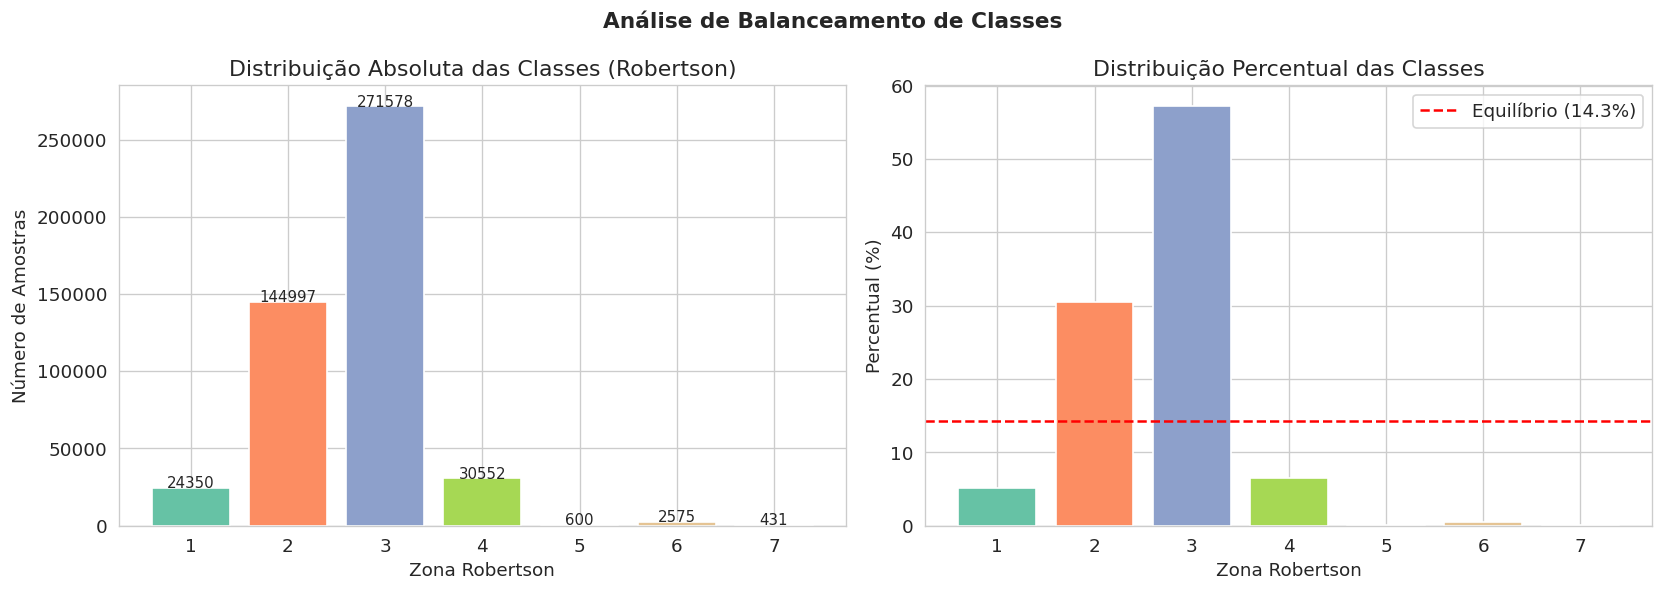


📊 Razão máx/mín de desbalanceamento: 630.1x
→ Será aplicado class_weight='balanced' no RF e SMOTE no treino.


In [58]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição absoluta
counts = df_feat['zone_robertson'].value_counts().sort_index()
axes[0].bar(counts.index.astype(str), counts.values,
            color=plt.cm.Set2(np.linspace(0, 1, len(counts))))
axes[0].set_title('Distribuição Absoluta das Classes (Robertson)')
axes[0].set_xlabel('Zona Robertson')
axes[0].set_ylabel('Número de Amostras')
for i, (k, v) in enumerate(counts.items()):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)

# Distribuição percentual com linha de equilíbrio
pct = counts / counts.sum() * 100
axes[1].bar(pct.index.astype(str), pct.values,
            color=plt.cm.Set2(np.linspace(0, 1, len(pct))))
axes[1].axhline(y=100/len(pct), color='red', linestyle='--',
                label=f'Equilíbrio ({100/len(pct):.1f}%)')
axes[1].set_title('Distribuição Percentual das Classes')
axes[1].set_xlabel('Zona Robertson')
axes[1].set_ylabel('Percentual (%)')
axes[1].legend()

plt.suptitle('Análise de Balanceamento de Classes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Razão de desbalanceamento
max_count = counts.max()
min_count = counts.min()
print(f"\n📊 Razão máx/mín de desbalanceamento: {max_count/min_count:.1f}x")
print("→ Será aplicado class_weight='balanced' no RF e SMOTE no treino.")



# ║  CÉLULA 8 — DEFINIÇÃO DE FEATURES E TARGET              ║


In [72]:

# Features para o MODELO SUPERVISIONADO (RF) — variáveis BRUTAS do
# ensaio. Qt, Fr, Bq e Ic foram TODOS excluídos: zone_robertson é
# calculado por robertson_classify(Ic, Bq), e Ic é uma função
# determinística de Qt e Fr — ou seja, usar Qt/Fr/Bq como features
# permite ao RF reconstruir a fórmula do próprio target quase
# perfeitamente (vazamento determinístico, não estatístico). Com
# depth/qc/fs/u2 brutos, o modelo precisa de fato aprender o padrão
# físico de solo a partir das medições originais do CPT.
FEATURES_RF = ['depth', 'qc', 'fs', 'u2']

# Features para o MODELO NÃO SUPERVISIONADO (K-Means)
# Aqui Qt/Fr/Bq são aceitáveis: o KMeans não usa o rótulo durante o
# treino, e a comparação com zone_robertson via ARI só acontece DEPOIS
# de formar os clusters — não há vazamento na etapa de ajuste do modelo.
FEATURES_KMEANS = ['Qt', 'Fr', 'Bq']   # Mesmo espaço de Robertson para comparabilidade

TARGET = 'zone_robertson'
GROUPS = 'borehole_id'

# Monta a lista de colunas necessárias sem duplicatas. 'depth', 'qc' e
# 'fs' já estão em FEATURES_RF — adicioná-los de novo explicitamente
# (como em versões anteriores desta célula) criava colunas DUPLICADAS
# em df_model, o que fazia df_model[FEATURES_RF] retornar mais colunas
# do que o esperado e quebrava o holdout silenciosamente. Usar um
# dict (Python 3.7+) remove duplicatas preservando a ordem original.
colunas_necessarias = list(dict.fromkeys(
    FEATURES_RF + FEATURES_KMEANS + [TARGET, GROUPS, 'Ic']
))

assert len(colunas_necessarias) == len(set(colunas_necessarias)), \
    "Ainda há colunas duplicadas na seleção — revise a lista acima."

df_model = df_feat[colunas_necessarias].dropna()

# X_rf, X_kmeans, y e groups são calculados na Célula 9 (Holdout),
# a partir de df_model + FEATURES_RF/FEATURES_KMEANS atuais. Mantê-los
# fora desta célula evita ter duas fontes da mesma informação que
# podem ficar desalinhadas se as células forem reexecutadas fora de
# ordem ao longo de edições do notebook.

print(f"✅ df_model pronto: {df_model.shape[0]:,} linhas, {df_model.shape[1]} colunas")
print(f"   FEATURES_RF     : {FEATURES_RF}")
print(f"   FEATURES_KMEANS : {FEATURES_KMEANS}")
print(f"   Classes únicas (target): {sorted(df_model[TARGET].unique())}")
print(f"   Grupos (furos)         : {df_model[GROUPS].nunique()}")


# ╔══════════════════════════════════════════════════════════╗
# ║  NOTA METODOLÓGICA — VAZAMENTO DETERMINÍSTICO            ║
# ║  (mover para célula Markdown na versão final do notebook) ║
# ╚══════════════════════════════════════════════════════════╝
"""
### Por que FEATURES_RF usa variáveis brutas (depth, qc, fs, u2)

Uma versão anterior deste pipeline usava `FEATURES_RF = ['Qt', 'Fr',
'Bq', 'depth']` — os índices normalizados de Robertson, sem incluir
`Ic` diretamente. A expectativa era que isso evitasse vazamento de
dados, já que `Ic` não aparecia entre as features.

Essa configuração produziu acurácia de validação cruzada de **99.8%**,
um valor estatisticamente implausível para um problema real de
classificação de solo a partir de medições de campo. A investigação
revelou a causa: o rótulo (`zone_robertson`) é definido por

    zone_robertson = robertson_classify(Ic, Bq)

e `Ic`, por sua vez, é uma **função determinística** de `Qt` e `Fr`:

    Ic = f(Qt, Fr)

Ou seja, mesmo sem `Ic` na lista de features, o modelo tinha acesso
direto a `Qt` e `Fr` — os únicos dois insumos necessários para
recalcular `Ic` com exatidão — além de `Bq`, que é usado *diretamente*
na função de classificação como discriminador entre as zonas 6 e 7.
Isso configura um **vazamento determinístico**: diferente do
vazamento estatístico clássico (quando uma feature é apenas
*correlacionada* com o rótulo), aqui a relação é uma fórmula
matemática exata. O Random Forest não estava aprendendo um padrão de
solo — estava reconstruindo a fórmula de Robertson a partir dos seus
próprios ingredientes.

**Correção aplicada:** `FEATURES_RF` passou a usar apenas as medições
brutas do ensaio CPT (`depth, qc, fs, u2`), sem nenhum índice
pré-calculado que participe da definição do rótulo. O `KMeans`
permanece usando `Qt, Fr, Bq` (`FEATURES_KMEANS`) porque, sendo não
supervisionado, ele não usa `zone_robertson` durante o ajuste dos
clusters — a comparação com Robertson (via ARI) só ocorre depois que
os clusters já foram formados, o que não constitui vazamento na etapa
de treino.

Esse achado é reportado aqui como parte do processo de validação do
MVP: a queda de acurácia esperada após a correção (de ~99.8% para uma
faixa mais modesta, plausível para o problema) é o resultado correto,
não uma regressão — reflete a diferença entre "decorar uma fórmula" e
"aprender um padrão físico a partir de dados brutos".
"""




✅ df_model pronto: 472,984 linhas, 10 colunas
   FEATURES_RF     : ['depth', 'qc', 'fs', 'u2']
   FEATURES_KMEANS : ['Qt', 'Fr', 'Bq']
   Classes únicas (target): [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
   Grupos (furos)         : 412


'\n### Por que FEATURES_RF usa variáveis brutas (depth, qc, fs, u2)\n\nUma versão anterior deste pipeline usava `FEATURES_RF = [\'Qt\', \'Fr\',\n\'Bq\', \'depth\']` — os índices normalizados de Robertson, sem incluir\n`Ic` diretamente. A expectativa era que isso evitasse vazamento de\ndados, já que `Ic` não aparecia entre as features.\n\nEssa configuração produziu acurácia de validação cruzada de **99.8%**,\num valor estatisticamente implausível para um problema real de\nclassificação de solo a partir de medições de campo. A investigação\nrevelou a causa: o rótulo (`zone_robertson`) é definido por\n\n    zone_robertson = robertson_classify(Ic, Bq)\n\ne `Ic`, por sua vez, é uma **função determinística** de `Qt` e `Fr`:\n\n    Ic = f(Qt, Fr)\n\nOu seja, mesmo sem `Ic` na lista de features, o modelo tinha acesso\ndireto a `Qt` e `Fr` — os únicos dois insumos necessários para\nrecalcular `Ic` com exatidão — além de `Bq`, que é usado *diretamente*\nna função de classificação como discrimina

# ║  CÉLULA 9 — HOLDOUT           ║

In [73]:
# ║  CÉLULA 9 — HOLDOUT COM SEPARAÇÃO POR GRUPO (FURO)      ║

assert list(df_model[FEATURES_RF].columns) == FEATURES_RF, \
    "df_model não contém todas as colunas de FEATURES_RF — confira a Célula 8."

X_rf     = df_model[FEATURES_RF].values
X_kmeans = df_model[FEATURES_KMEANS].values
y        = df_model[TARGET].values
groups   = df_model[GROUPS].values

print(f"Recalculado nesta célula — X_rf.shape: {X_rf.shape} "
      f"(esperado: N linhas x {len(FEATURES_RF)} colunas)")
assert X_rf.shape[1] == len(FEATURES_RF), (
    f"X_rf tem {X_rf.shape[1]} colunas, mas FEATURES_RF tem "
    f"{len(FEATURES_RF)} ({FEATURES_RF}). Verifique df_model."
)

gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, test_idx = next(gss.split(X_rf, y, groups=groups))

X_train_rf, X_test_rf = X_rf[train_idx], X_rf[test_idx]
X_train_km, X_test_km = X_kmeans[train_idx], X_kmeans[test_idx]
y_train, y_test       = y[train_idx], y[test_idx]
groups_train          = groups[train_idx]

Recalculado nesta célula — X_rf.shape: (472984, 4) (esperado: N linhas x 4 colunas)


In [74]:
print("FEATURES_RF atual          :", FEATURES_RF)
print("df_model.columns           :", list(df_model.columns))
print()
print("Colunas de FEATURES_RF ausentes em df_model:")
for col in FEATURES_RF:
    presente = col in df_model.columns
    print(f"  {col:<10} : {'✅ presente' if presente else '❌ AUSENTE'}")

FEATURES_RF atual          : ['depth', 'qc', 'fs', 'u2']
df_model.columns           : ['depth', 'qc', 'fs', 'u2', 'Qt', 'Fr', 'Bq', 'zone_robertson', 'borehole_id', 'Ic']

Colunas de FEATURES_RF ausentes em df_model:
  depth      : ✅ presente
  qc         : ✅ presente
  fs         : ✅ presente
  u2         : ✅ presente


# ║  CÉLULA 10 — PIPELINE MODELO 1: RANDOM FOREST           ║


*   List item
*   List item



In [75]:

# Usar ImbPipeline (imblearn) para que o SMOTE seja aplicado
# APENAS no fold de treino durante a validação cruzada

pipeline_rf = ImbPipeline(steps=[
    ('scaler',  RobustScaler()),
    ('smote',   SMOTE(
                    random_state=SEED,
                    k_neighbors=3,
                    sampling_strategy='minority'   # oversample apenas a minoritária
                )),
    ('clf',     RandomForestClassifier(
                    n_estimators=100,
                    max_depth=5,
                    min_samples_leaf=5,
                    max_features='sqrt',
                    class_weight='balanced',
                    random_state=SEED,
                    n_jobs=-1
                ))
], verbose=False)

print("✅ Pipeline RF definido:")
print(pipeline_rf)



✅ Pipeline RF definido:
Pipeline(steps=[('scaler', RobustScaler()),
                ('smote',
                 SMOTE(k_neighbors=3, random_state=42,
                       sampling_strategy='minority')),
                ('clf',
                 RandomForestClassifier(class_weight='balanced', max_depth=5,
                                        min_samples_leaf=5, n_jobs=-1,
                                        random_state=42))])


# ║  CÉLULA 11 — VALIDAÇÃO CRUZADA (GroupKFold)             ║


In [76]:

gkf = GroupKFold(n_splits=5)

cv_results = cross_validate(
    pipeline_rf,
    X_train_rf, y_train,
    groups=groups_train,
    cv=gkf,
    scoring=['accuracy', 'f1_weighted'],
    return_train_score=True,
    n_jobs=-1
)

print("=" * 50)
print("📊 RESULTADOS DA VALIDAÇÃO CRUZADA (GroupKFold, k=5)")
print("=" * 50)
for metric in ['accuracy', 'f1_weighted']:
    train_scores = cv_results[f'train_{metric}']
    val_scores   = cv_results[f'test_{metric}']
    print(f"\n  {metric.upper()}:")
    print(f"    Treino : {train_scores.mean():.4f} ± {train_scores.std():.4f}")
    print(f"    Val.   : {val_scores.mean():.4f} ± {val_scores.std():.4f}")

overfit_flag = cv_results['train_accuracy'].mean() - cv_results['test_accuracy'].mean()
print(f"\n  Gap Treino-Validação (accuracy): {overfit_flag:.4f}")
if overfit_flag > 0.1:
    print("  ⚠️ Possível overfitting — considerar aumentar min_samples_leaf ou reduzir max_depth.")
else:
    print("  ✅ Gap dentro de limite aceitável.")



📊 RESULTADOS DA VALIDAÇÃO CRUZADA (GroupKFold, k=5)

  ACCURACY:
    Treino : 0.8142 ± 0.0056
    Val.   : 0.8080 ± 0.0081

  F1_WEIGHTED:
    Treino : 0.8229 ± 0.0048
    Val.   : 0.8172 ± 0.0081

  Gap Treino-Validação (accuracy): 0.0062
  ✅ Gap dentro de limite aceitável.


# ║  CÉLULA 12 — TREINAMENTO FINAL DO RF NO CONJUNTO TREINO ║


In [77]:

pipeline_rf.fit(X_train_rf, y_train)
y_pred_rf = pipeline_rf.predict(X_test_rf)

print("=" * 55)
print("📊 AVALIAÇÃO MODELO 1 — RANDOM FOREST (conjunto teste)")
print("=" * 55)
print(f"\n  Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"  Cohen's κ : {cohen_kappa_score(y_test, y_pred_rf):.4f}")

print("\n--- Relatório por Classe ---")
print(classification_report(y_test, y_pred_rf, zero_division=0))



📊 AVALIAÇÃO MODELO 1 — RANDOM FOREST (conjunto teste)

  Accuracy  : 0.8248
  F1-Score  : 0.8341
  Cohen's κ : 0.7159

--- Relatório por Classe ---
              precision    recall  f1-score   support

           1       0.71      0.93      0.81      8450
           2       0.80      0.85      0.83     40444
           3       0.96      0.79      0.86     83115
           4       0.48      0.95      0.64      9118
           5       0.17      0.91      0.29       141
           6       0.80      0.88      0.84       159
           7       0.87      0.91      0.89        90

    accuracy                           0.82    141517
   macro avg       0.68      0.89      0.74    141517
weighted avg       0.87      0.82      0.83    141517



# ║  CÉLULA 13 — CONFUSION MATRIX — RF vs ROBERTSON         ║


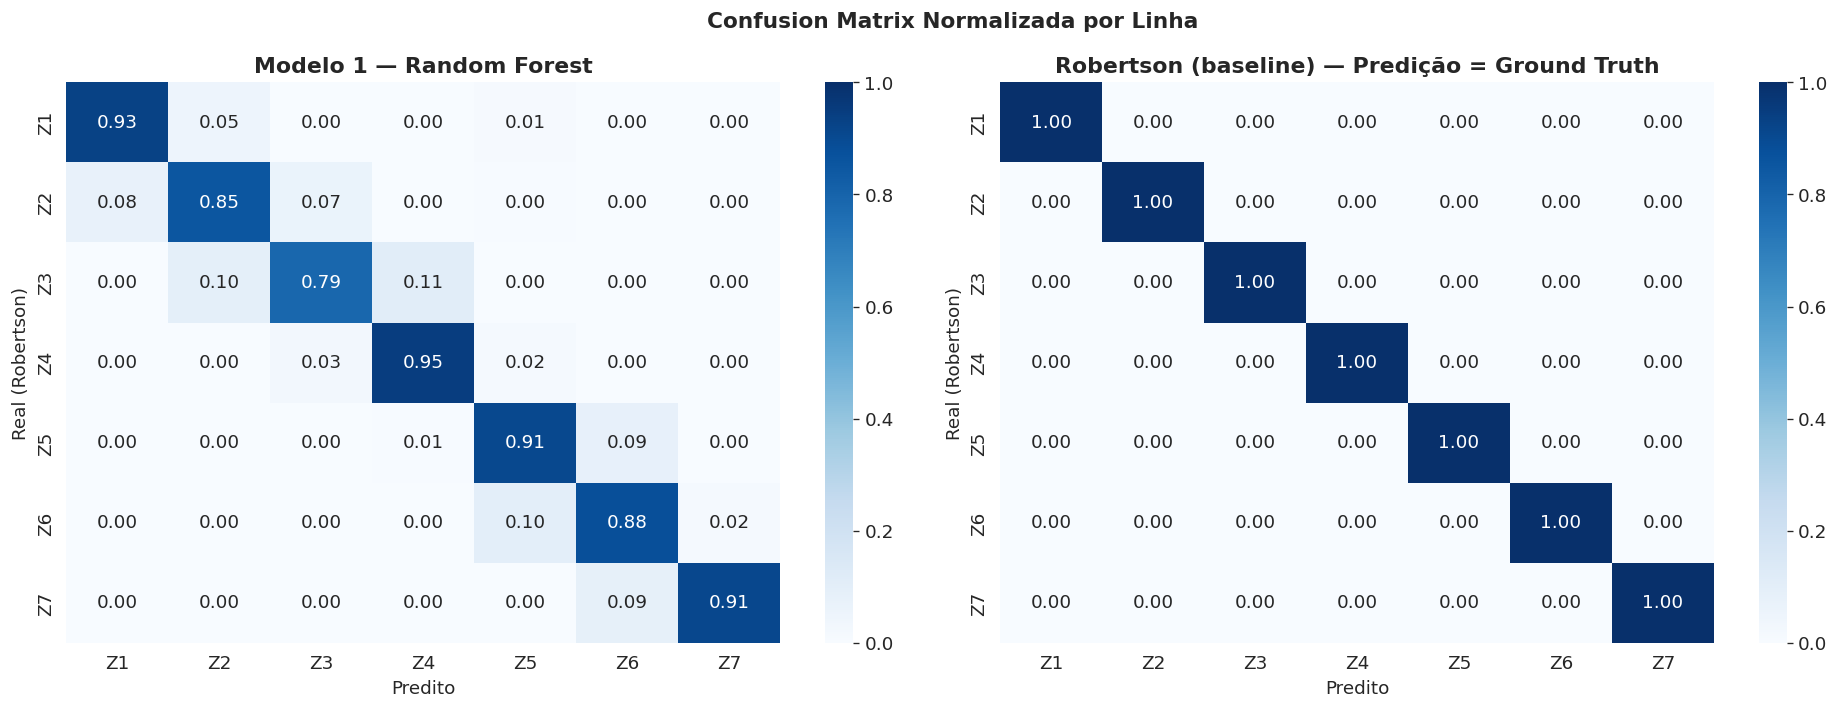

In [78]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

classes = sorted(np.unique(np.concatenate([y_test, y_pred_rf])))

for ax, (y_pred, title) in zip(axes, [
    (y_pred_rf, 'Modelo 1 — Random Forest'),
    (y_test,    'Robertson (baseline) — Predição = Ground Truth')
]):
    cm = confusion_matrix(y_test, y_pred, labels=classes, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=[f'Z{c}' for c in classes],
                yticklabels=[f'Z{c}' for c in classes],
                ax=ax, vmin=0, vmax=1)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real (Robertson)')

plt.suptitle('Confusion Matrix Normalizada por Linha', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()




# ║  CÉLULA 14 — FEATURE IMPORTANCE (RF)                    ║


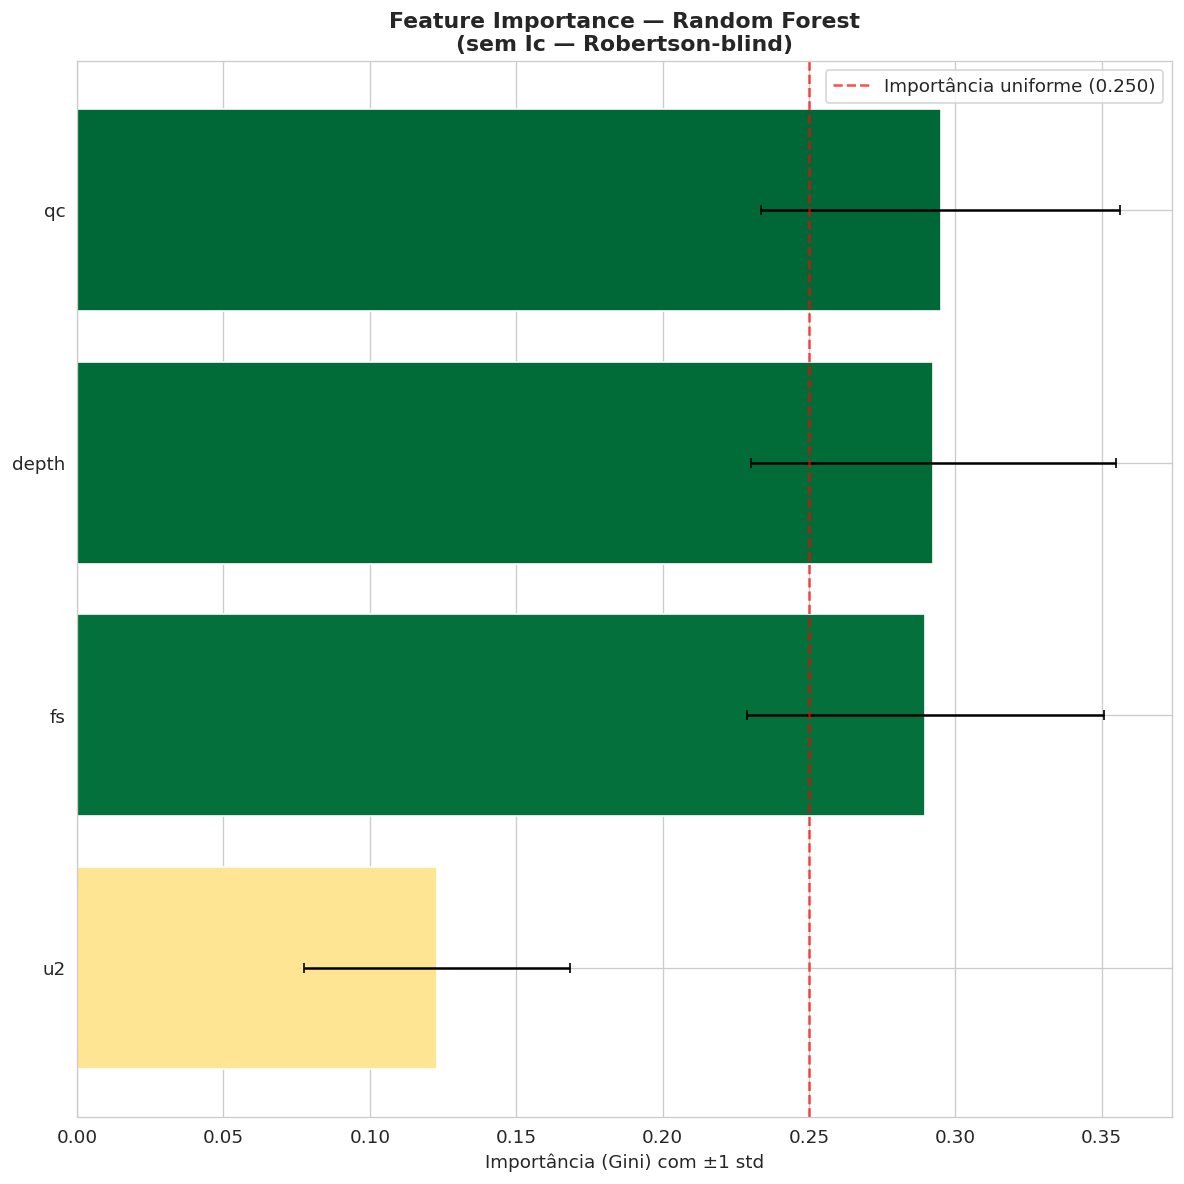


🔍 Top 5 features mais importantes:
feature  importance      std
     u2    0.122907 0.045509
     fs    0.289676 0.060916
  depth    0.292497 0.062246
     qc    0.294920 0.061386


In [80]:

rf_model   = pipeline_rf.named_steps['clf']
importances = rf_model.feature_importances_
std_imp     = np.std([tree.feature_importances_ for tree in rf_model.estimators_], axis=0)

feat_imp_df = pd.DataFrame({
    'feature':    FEATURES_RF,
    'importance': importances,
    'std':        std_imp
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
colors = plt.cm.RdYlGn(feat_imp_df['importance'] / feat_imp_df['importance'].max())
bars = ax.barh(feat_imp_df['feature'], feat_imp_df['importance'],
               xerr=feat_imp_df['std'], color=colors, capsize=3)
ax.set_xlabel('Importância (Gini) com ±1 std')
ax.set_title('Feature Importance — Random Forest\n(sem Ic — Robertson-blind)',
             fontweight='bold')
ax.axvline(x=1/len(FEATURES_RF), color='red', linestyle='--', alpha=0.7,
           label=f'Importância uniforme ({1/len(FEATURES_RF):.3f})')
ax.legend()
plt.tight_layout()
plt.show()

print("\n🔍 Top 5 features mais importantes:")
print(feat_imp_df.tail(5)[['feature', 'importance', 'std']].to_string(index=False))



# ║  CÉLULA 15 — ANÁLISE SHAP                               ║


ValueError: All arrays must be of the same length

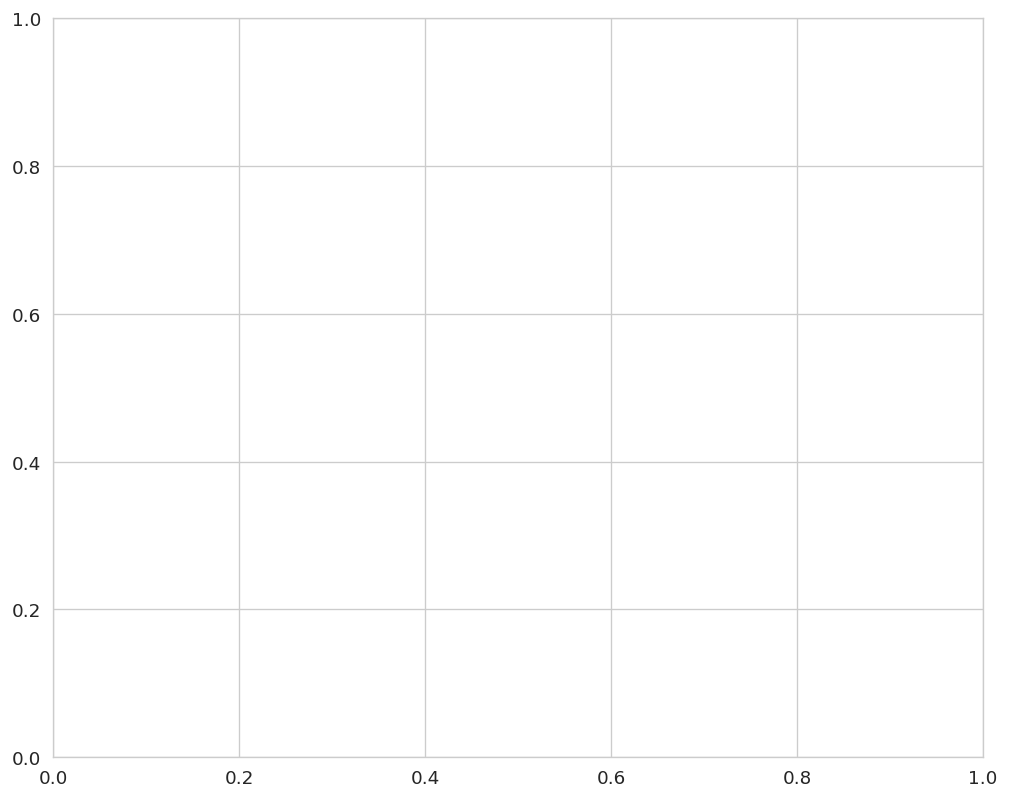

In [82]:

# Transformar X_test pelo scaler do pipeline (SHAP precisa dos dados escalados)
scaler_fitted = pipeline_rf.named_steps['scaler']
X_test_scaled = scaler_fitted.transform(X_test_rf)

# Criar explainer SHAP para RF
explainer    = shap.TreeExplainer(rf_model)
shap_values  = explainer.shap_values(X_test_scaled)   # shape: (n_classes, n_amostras, n_features)

# Summary plot — importância SHAP global (média de todas as classes)
shap_abs_mean = np.mean([np.abs(sv) for sv in shap_values], axis=0)  # (n_amostras, n_features)

fig, ax = plt.subplots(figsize=(10, 8))
shap_mean_feat = shap_abs_mean.mean(axis=0)
feat_shap_df = pd.DataFrame({
    'feature':    FEATURES_RF,
    'shap_mean':  shap_mean_feat
}).sort_values('shap_mean', ascending=True)

colors = plt.cm.viridis(feat_shap_df['shap_mean'] / feat_shap_df['shap_mean'].max())
ax.barh(feat_shap_df['feature'], feat_shap_df['shap_mean'], color=colors)
ax.set_xlabel('|SHAP value| médio (todas as classes)')
ax.set_title('Importância Global — SHAP Values\n(confirmação independente do feature_importances_)',
             fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Interpretação: SHAP corrobora ou diverge do feature_importances_?")
top_rf   = feat_imp_df.tail(5)['feature'].tolist()
top_shap = feat_shap_df.tail(5)['feature'].tolist()
overlap  = set(top_rf) & set(top_shap)
print(f"   Top-5 RF Gini : {top_rf}")
print(f"   Top-5 SHAP    : {top_shap}")
print(f"   Sobreposição  : {overlap} ({len(overlap)}/5 features em comum)")


# ║  CÉLULA 16 — PIPELINE K-MEANS                           ║


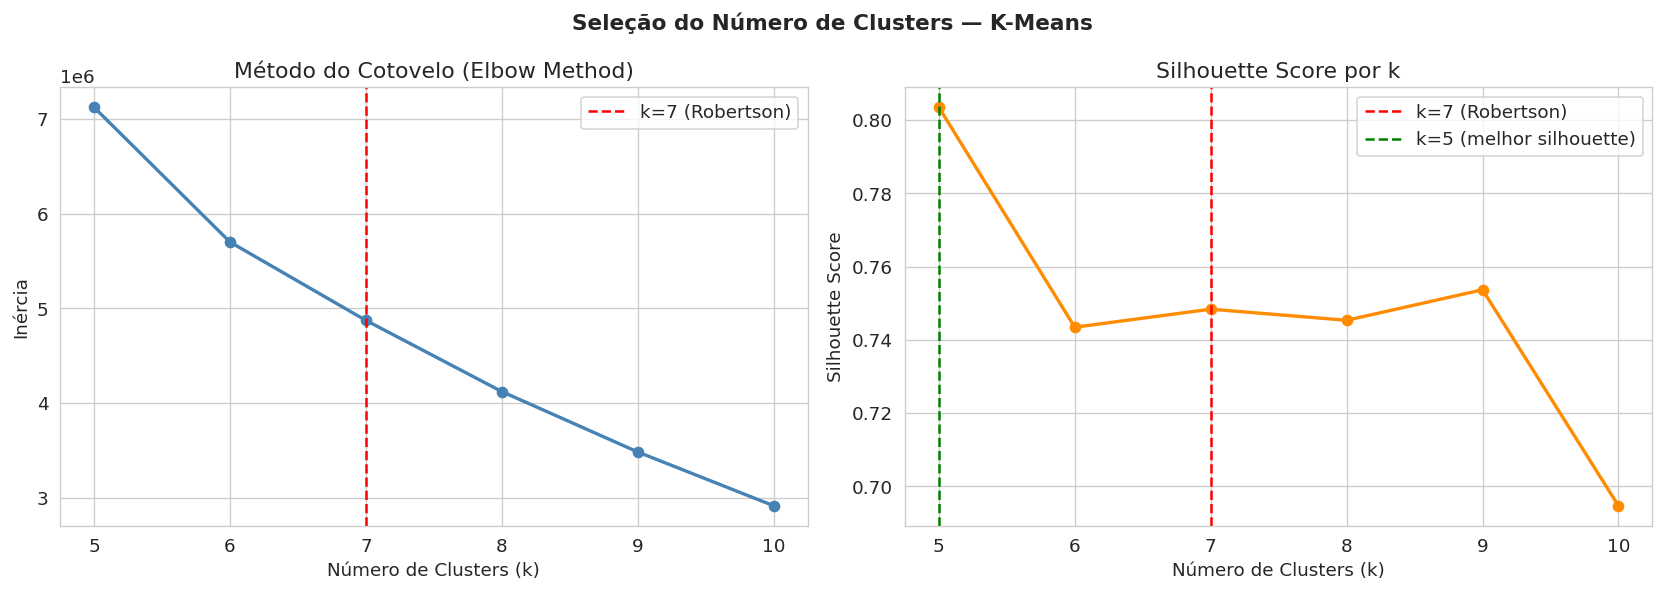


   k Robertson   : 7
   Melhor k (sil): 5
   → Usando k=7 para comparabilidade com Robertson.


In [83]:

# K-Means opera no espaço (Qt, Fr, Bq) — mesmo espaço de Robertson
# Scaler separado para não contaminar o pipeline RF

scaler_km  = RobustScaler()
X_train_km_scaled = scaler_km.fit_transform(X_train_km)
X_test_km_scaled  = scaler_km.transform(X_test_km)

# ── Seleção do número de clusters ──────────────────────────
n_classes = len(np.unique(y))
k_range   = range(n_classes - 2, n_classes + 4)

inertia_list, silhouette_list = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=20, max_iter=500)
    labels = km.fit_predict(X_train_km_scaled)
    inertia_list.append(km.inertia_)
    sil = silhouette_score(X_train_km_scaled, labels,
                           metric='euclidean', sample_size=5000,
                           random_state=SEED)
    silhouette_list.append(sil)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertia_list, 'o-', color='steelblue', linewidth=2)
axes[0].set_xlabel('Número de Clusters (k)')
axes[0].set_ylabel('Inércia')
axes[0].set_title('Método do Cotovelo (Elbow Method)')
axes[0].axvline(x=n_classes, color='red', linestyle='--', label=f'k={n_classes} (Robertson)')
axes[0].legend()

axes[1].plot(list(k_range), silhouette_list, 'o-', color='darkorange', linewidth=2)
axes[1].set_xlabel('Número de Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por k')
axes[1].axvline(x=n_classes, color='red', linestyle='--', label=f'k={n_classes} (Robertson)')
best_k = list(k_range)[np.argmax(silhouette_list)]
axes[1].axvline(x=best_k, color='green', linestyle='--', label=f'k={best_k} (melhor silhouette)')
axes[1].legend()

plt.suptitle('Seleção do Número de Clusters — K-Means', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n   k Robertson   : {n_classes}")
print(f"   Melhor k (sil): {best_k}")
print(f"   → Usando k={n_classes} para comparabilidade com Robertson.")



# ║  CÉLULA 17 — TREINAMENTO K-MEANS FINAL                  ║


In [84]:

kmeans = KMeans(
    n_clusters=n_classes,
    random_state=SEED,
    n_init=30,
    max_iter=500
)
kmeans.fit(X_train_km_scaled)

labels_train_raw = kmeans.labels_
labels_test_raw  = kmeans.predict(X_test_km_scaled)

sil_train = silhouette_score(X_train_km_scaled, labels_train_raw,
                              metric='euclidean', sample_size=5000,
                              random_state=SEED)

print(f"✅ K-Means treinado com k={n_classes}")
print(f"   Silhouette Score (treino): {sil_train:.4f}")
print(f"   Inércia final           : {kmeans.inertia_:.2f}")


✅ K-Means treinado com k=7
   Silhouette Score (treino): 0.7484
   Inércia final           : 4873253.55


# ║  CÉLULA 18 — MECANISMOS DE CORRESPONDÊNCIA              ║


🔗 MECANISMO 1 — Mapeamento por Maioria (Treino)
   Cluster 0 → Zona Robertson 3
   Cluster 1 → Zona Robertson 1
   Cluster 2 → Zona Robertson 2
   Cluster 3 → Zona Robertson 3
   Cluster 4 → Zona Robertson 2
   Cluster 5 → Zona Robertson 4
   Cluster 6 → Zona Robertson 2

🔗 MECANISMO 2 — Algoritmo Húngaro (Treino)
   Cluster 0 → Zona Robertson 3
   Cluster 1 → Zona Robertson 7
   Cluster 2 → Zona Robertson 5
   Cluster 3 → Zona Robertson 6
   Cluster 4 → Zona Robertson 1
   Cluster 5 → Zona Robertson 4
   Cluster 6 → Zona Robertson 2


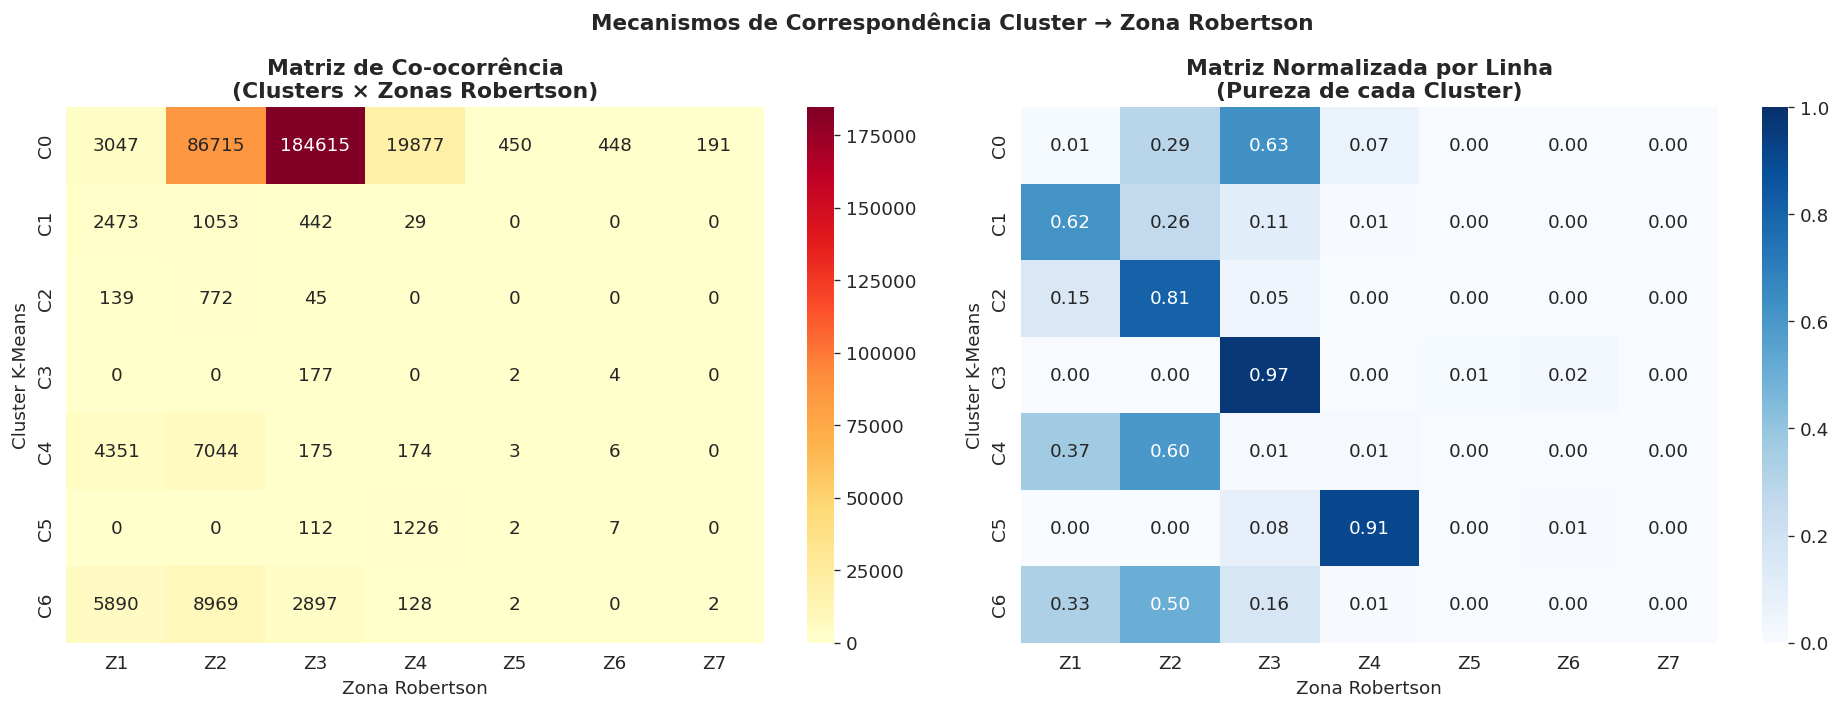

In [85]:

# ── Mecanismo 1: Mapeamento por Maioria ───────────────────
def majority_mapping(cluster_labels, true_labels):
    """
    Para cada cluster, atribui a classe Robertson mais frequente.
    Retorna: dict {cluster_id: classe_robertson}
    """
    classes = np.unique(true_labels)
    mapping = {}
    for c in np.unique(cluster_labels):
        mask  = cluster_labels == c
        votes = true_labels[mask]
        mapping[c] = pd.Series(votes).mode()[0]
    return mapping


# ── Mecanismo 2: Algoritmo Húngaro ───────────────────────
def hungarian_mapping(cluster_labels, true_labels):
    """
    Encontra o mapeamento ótimo (maximiza concordância global)
    usando o Algoritmo Húngaro (scipy.optimize.linear_sum_assignment).

    Retorna: dict {cluster_id: classe_robertson}
    """
    unique_clusters = np.unique(cluster_labels)
    unique_classes  = np.unique(true_labels)

    # Construir matriz de co-ocorrência (linhas=clusters, colunas=classes)
    cost_matrix = np.zeros((len(unique_clusters), len(unique_classes)), dtype=int)
    for i, c in enumerate(unique_clusters):
        for j, z in enumerate(unique_classes):
            cost_matrix[i, j] = np.sum((cluster_labels == c) & (true_labels == z))

    # linear_sum_assignment MINIMIZA custo → usar negativo para MAXIMIZAR
    row_ind, col_ind = linear_sum_assignment(-cost_matrix)

    mapping = {}
    for r, c in zip(row_ind, col_ind):
        mapping[unique_clusters[r]] = unique_classes[c]

    return mapping, cost_matrix, unique_clusters, unique_classes


# Aplicar os dois mecanismos no conjunto de TREINO
map_majority = majority_mapping(labels_train_raw, y_train)
map_hungarian, cost_matrix, u_clusters, u_classes = hungarian_mapping(
    labels_train_raw, y_train
)

print("=" * 55)
print("🔗 MECANISMO 1 — Mapeamento por Maioria (Treino)")
print("=" * 55)
for cluster, zone in sorted(map_majority.items()):
    print(f"   Cluster {cluster} → Zona Robertson {zone}")

print("\n" + "=" * 55)
print("🔗 MECANISMO 2 — Algoritmo Húngaro (Treino)")
print("=" * 55)
for cluster, zone in sorted(map_hungarian.items()):
    print(f"   Cluster {cluster} → Zona Robertson {zone}")

# Visualizar a Matriz de Co-ocorrência usada pelo Húngaro
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matriz de co-ocorrência (contagem)
sns.heatmap(cost_matrix, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=[f'Z{c}' for c in u_classes],
            yticklabels=[f'C{c}' for c in u_clusters],
            ax=axes[0])
axes[0].set_title('Matriz de Co-ocorrência\n(Clusters × Zonas Robertson)', fontweight='bold')
axes[0].set_xlabel('Zona Robertson')
axes[0].set_ylabel('Cluster K-Means')

# Matriz normalizada por linha (% de cada cluster em cada zona)
cost_norm = cost_matrix / (cost_matrix.sum(axis=1, keepdims=True) + 1e-9)
sns.heatmap(cost_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[f'Z{c}' for c in u_classes],
            yticklabels=[f'C{c}' for c in u_clusters],
            ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Matriz Normalizada por Linha\n(Pureza de cada Cluster)', fontweight='bold')
axes[1].set_xlabel('Zona Robertson')
axes[1].set_ylabel('Cluster K-Means')

plt.suptitle('Mecanismos de Correspondência Cluster → Zona Robertson',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



# ║  CÉLULA 19 — AVALIAÇÃO K-MEANS (mapeado) vs ROBERTSON   ║


In [86]:

# Aplicar mapeamento Húngaro no teste
y_pred_km = np.array([map_hungarian.get(l, -1) for l in labels_test_raw])

print("=" * 55)
print("📊 AVALIAÇÃO MODELO 2 — K-MEANS (mapeamento húngaro)")
print("=" * 55)
print(f"\n  Accuracy  : {accuracy_score(y_test, y_pred_km):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_km, average='weighted', zero_division=0):.4f}")
print(f"  Cohen's κ : {cohen_kappa_score(y_test, y_pred_km):.4f}")

print("\n--- Métricas não supervisionadas ---")
ari = adjusted_rand_score(y_test, labels_test_raw)
nmi = normalized_mutual_info_score(y_test, labels_test_raw)
sil_test = silhouette_score(X_test_km_scaled, labels_test_raw)
print(f"  ARI (Adjusted Rand Index)       : {ari:.4f}")
print(f"  NMI (Normalized Mutual Info)    : {nmi:.4f}")
print(f"  Silhouette Score (teste)        : {sil_test:.4f}")

# Comparar mapeamento por maioria vs húngaro
y_pred_km_majority = np.array([map_majority.get(l, -1) for l in labels_test_raw])
print("\n--- Comparação dos mecanismos de mapeamento ---")
print(f"  Accuracy (Maioria)  : {accuracy_score(y_test, y_pred_km_majority):.4f}")
print(f"  Accuracy (Húngaro)  : {accuracy_score(y_test, y_pred_km):.4f}")



📊 AVALIAÇÃO MODELO 2 — K-MEANS (mapeamento húngaro)

  Accuracy  : 0.6217
  F1-Score  : 0.5262
  Cohen's κ : 0.1712

--- Métricas não supervisionadas ---
  ARI (Adjusted Rand Index)       : 0.1758
  NMI (Normalized Mutual Info)    : 0.1825
  Silhouette Score (teste)        : 0.7342

--- Comparação dos mecanismos de mapeamento ---
  Accuracy (Maioria)  : 0.6367
  Accuracy (Húngaro)  : 0.6217


# ║  CÉLULA 20 — COMPARAÇÃO GLOBAL DOS MODELOS              ║


📊 COMPARAÇÃO FINAL DOS MODELOS
                      Accuracy      F1-W     Kappa                Tipo
Robertson (Baseline)       1.0       1.0       1.0      Determinístico
Random Forest (M1)    0.824848  0.834143  0.715927      Supervisionado
K-Means (M2)          0.621671  0.526244  0.171153  Não Supervisionado


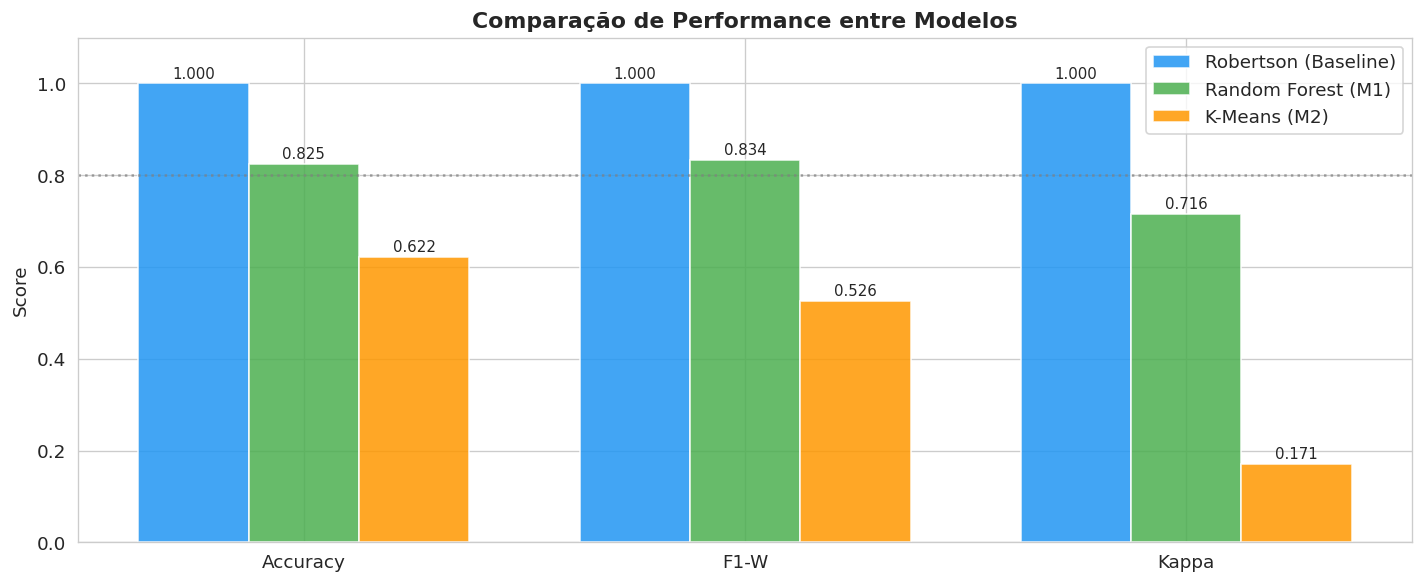

In [87]:

# Recalcular Robertson no conjunto de teste para comparação
df_test = df_model.iloc[test_idx].copy()
y_robertson = df_test['zone_robertson'].values   # baseline determinístico

metrics = {
    'Robertson (Baseline)': {
        'Accuracy':  accuracy_score(y_test, y_robertson),
        'F1-W':      f1_score(y_test, y_robertson, average='weighted', zero_division=0),
        'Kappa':     cohen_kappa_score(y_test, y_robertson),
        'Tipo':      'Determinístico'
    },
    'Random Forest (M1)': {
        'Accuracy':  accuracy_score(y_test, y_pred_rf),
        'F1-W':      f1_score(y_test, y_pred_rf, average='weighted', zero_division=0),
        'Kappa':     cohen_kappa_score(y_test, y_pred_rf),
        'Tipo':      'Supervisionado'
    },
    'K-Means (M2)': {
        'Accuracy':  accuracy_score(y_test, y_pred_km),
        'F1-W':      f1_score(y_test, y_pred_km, average='weighted', zero_division=0),
        'Kappa':     cohen_kappa_score(y_test, y_pred_km),
        'Tipo':      'Não Supervisionado'
    }
}

df_metrics = pd.DataFrame(metrics).T
print("=" * 65)
print("📊 COMPARAÇÃO FINAL DOS MODELOS")
print("=" * 65)
print(df_metrics.to_string())

# Gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(12, 5))
metric_names = ['Accuracy', 'F1-W', 'Kappa']
x = np.arange(len(metric_names))
width = 0.25
colors_models = ['#2196F3', '#4CAF50', '#FF9800']

for i, (model_name, row) in enumerate(df_metrics.iterrows()):
    vals = [row[m] for m in metric_names]
    bars = ax.bar(x + i * width, vals, width, label=model_name,
                  color=colors_models[i], alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Comparação de Performance entre Modelos', fontweight='bold')
ax.legend()
ax.axhline(y=0.8, color='gray', linestyle=':', alpha=0.7, label='Referência 0.80')
plt.tight_layout()
plt.show()


# ║  CÉLULA 21 — VISUALIZAÇÃO DO PERFIL CPT COMPARATIVO     ║


🔍 Visualizando perfil do Furo @Aranui_1 (conjunto de teste)...


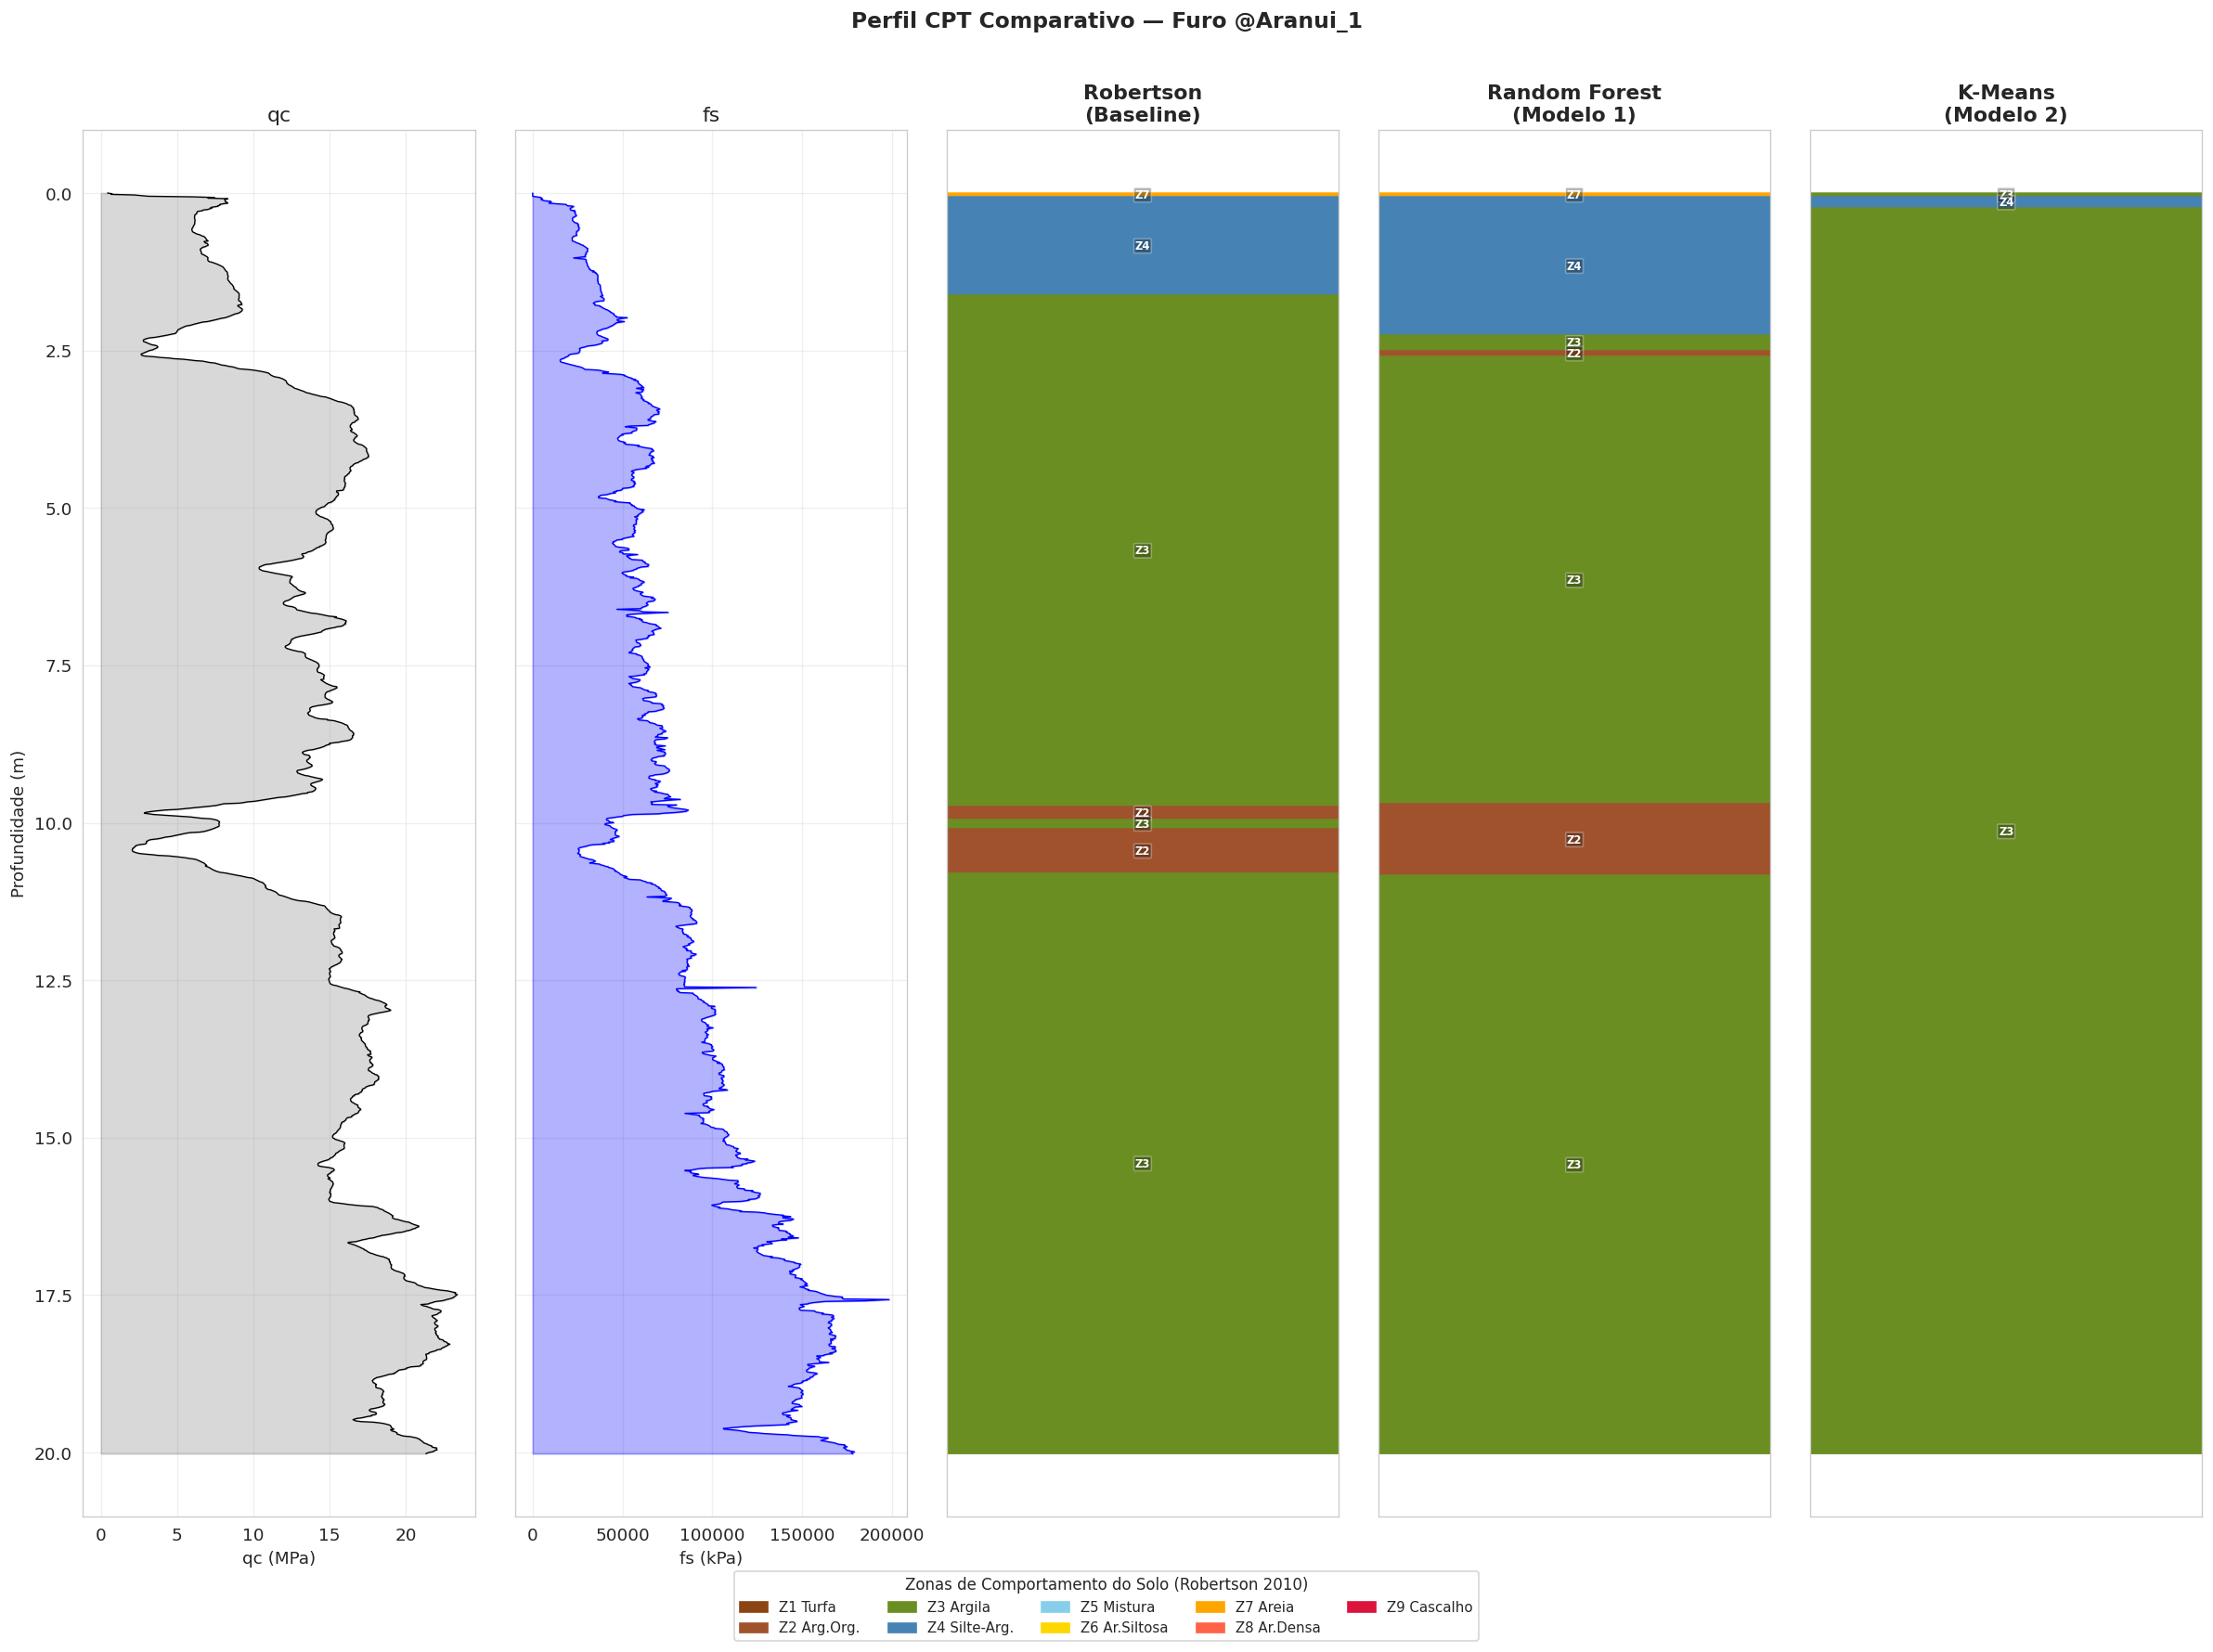

In [88]:

# Paleta de cores padronizada para zonas Robertson (1 a 9)
ZONE_COLORS = {
    1: '#8B4513',   # turfa — marrom escuro
    2: '#A0522D',   # argila orgânica — marrom
    3: '#6B8E23',   # argila — verde oliva
    4: '#4682B4',   # silte argiloso — azul aço
    5: '#87CEEB',   # mistura — azul claro
    6: '#FFD700',   # areia siltosa — amarelo
    7: '#FFA500',   # areia — laranja
    8: '#FF6347',   # areia densa — vermelho tomate
    9: '#DC143C',   # areia/cascalho — vermelho escuro
}

ZONE_LABELS = {
    1: 'Z1 Turfa',
    2: 'Z2 Arg.Org.',
    3: 'Z3 Argila',
    4: 'Z4 Silte-Arg.',
    5: 'Z5 Mistura',
    6: 'Z6 Ar.Siltosa',
    7: 'Z7 Areia',
    8: 'Z8 Ar.Densa',
    9: 'Z9 Cascalho',
}

def plot_cpt_profile(df_bh, rf_pipeline, km_model, km_scaler, km_mapping,
                     borehole_id, features_rf, features_km):
    """
    Gera o perfil CPT comparativo com 5 painéis:
    [qc | fs | Robertson | Random Forest | K-Means]
    """
    df = df_bh[df_bh['borehole_id'] == borehole_id].copy()
    df = df.sort_values('depth')
    depth = df['depth'].values

    # Predições
    X_rf_bh = df[features_rf].values
    X_km_bh = df[features_km].values

    pred_rf = rf_pipeline.predict(X_rf_bh)
    pred_km_raw = km_model.predict(km_scaler.transform(X_km_bh))
    pred_km = np.array([km_mapping.get(l, -1) for l in pred_km_raw])
    robertson = df['zone_robertson'].values

    fig, axes = plt.subplots(1, 5, figsize=(20, 14), sharey=True)
    fig.suptitle(f'Perfil CPT Comparativo — Furo {borehole_id}',
                 fontsize=14, fontweight='bold', y=1.01)

    # ── Painel 1: qc ─────────────────────────────────────
    axes[0].plot(df['qc'], depth, 'k-', linewidth=0.8)
    axes[0].fill_betweenx(depth, 0, df['qc'], alpha=0.3, color='gray')
    axes[0].set_xlabel('qc (MPa)')
    axes[0].set_ylabel('Profundidade (m)')
    axes[0].set_title('qc')
    axes[0].invert_yaxis()
    axes[0].grid(True, alpha=0.3)

    # ── Painel 2: fs ─────────────────────────────────────
    axes[1].plot(df['fs'] * 1000, depth, 'b-', linewidth=0.8)
    axes[1].fill_betweenx(depth, 0, df['fs'] * 1000, alpha=0.3, color='blue')
    axes[1].set_xlabel('fs (kPa)')
    axes[1].set_title('fs')
    axes[1].grid(True, alpha=0.3)

    # ── Painéis 3–5: classificações ──────────────────────
    for ax, (preds, title) in zip(
        axes[2:],
        [
            (robertson, 'Robertson\n(Baseline)'),
            (pred_rf,   'Random Forest\n(Modelo 1)'),
            (pred_km,   'K-Means\n(Modelo 2)'),
        ]
    ):
        # Criar barras coloridas por zona
        for i in range(len(depth) - 1):
            zone = preds[i]
            color = ZONE_COLORS.get(zone, '#CCCCCC')
            ax.fill_betweenx(
                [depth[i], depth[i+1]],
                0, 1,
                color=color, alpha=0.85
            )

        ax.set_xlim(0, 1)
        ax.set_xticks([])
        ax.set_title(title, fontweight='bold')
        ax.grid(False)

        # Adicionar rótulo da zona no centro de cada segmento
        zone_changes = np.where(np.diff(preds) != 0)[0]
        segments = np.split(np.arange(len(depth)), zone_changes + 1)
        for seg in segments:
            if len(seg) > 5:   # só rotular segmentos suficientemente espessos
                mid = seg[len(seg)//2]
                ax.text(0.5, depth[mid],
                        f'Z{preds[mid]}',
                        ha='center', va='center',
                        fontsize=7, fontweight='bold',
                        color='white',
                        bbox=dict(boxstyle='round,pad=0.1',
                                  facecolor='black', alpha=0.3))

    # Legenda global
    legend_patches = [
        mpatches.Patch(color=ZONE_COLORS.get(z, '#CCCCCC'),
                       label=ZONE_LABELS.get(z, f'Z{z}'))
        for z in sorted(ZONE_COLORS.keys())
    ]
    fig.legend(handles=legend_patches,
               loc='lower center', ncol=5,
               bbox_to_anchor=(0.5, -0.04),
               fontsize=9,
               title='Zonas de Comportamento do Solo (Robertson 2010)',
               title_fontsize=10)

    plt.tight_layout()
    plt.show()
    return fig


# Selecionar um furo de teste para visualização
test_borehole_ids = sorted(test_boreholes)
selected_bh = test_borehole_ids[0]   # primeiro furo do conjunto de teste

print(f"🔍 Visualizando perfil do Furo {selected_bh} (conjunto de teste)...")

fig_profile = plot_cpt_profile(
    df_bh        = df_model,
    rf_pipeline  = pipeline_rf,
    km_model     = kmeans,
    km_scaler    = scaler_km,
    km_mapping   = map_hungarian,
    borehole_id  = selected_bh,
    features_rf  = FEATURES_RF,
    features_km  = FEATURES_KMEANS
)


# ║  CÉLULA 22 — CONCORDÂNCIA PROFUNDIDADE A PROFUNDIDADE   ║


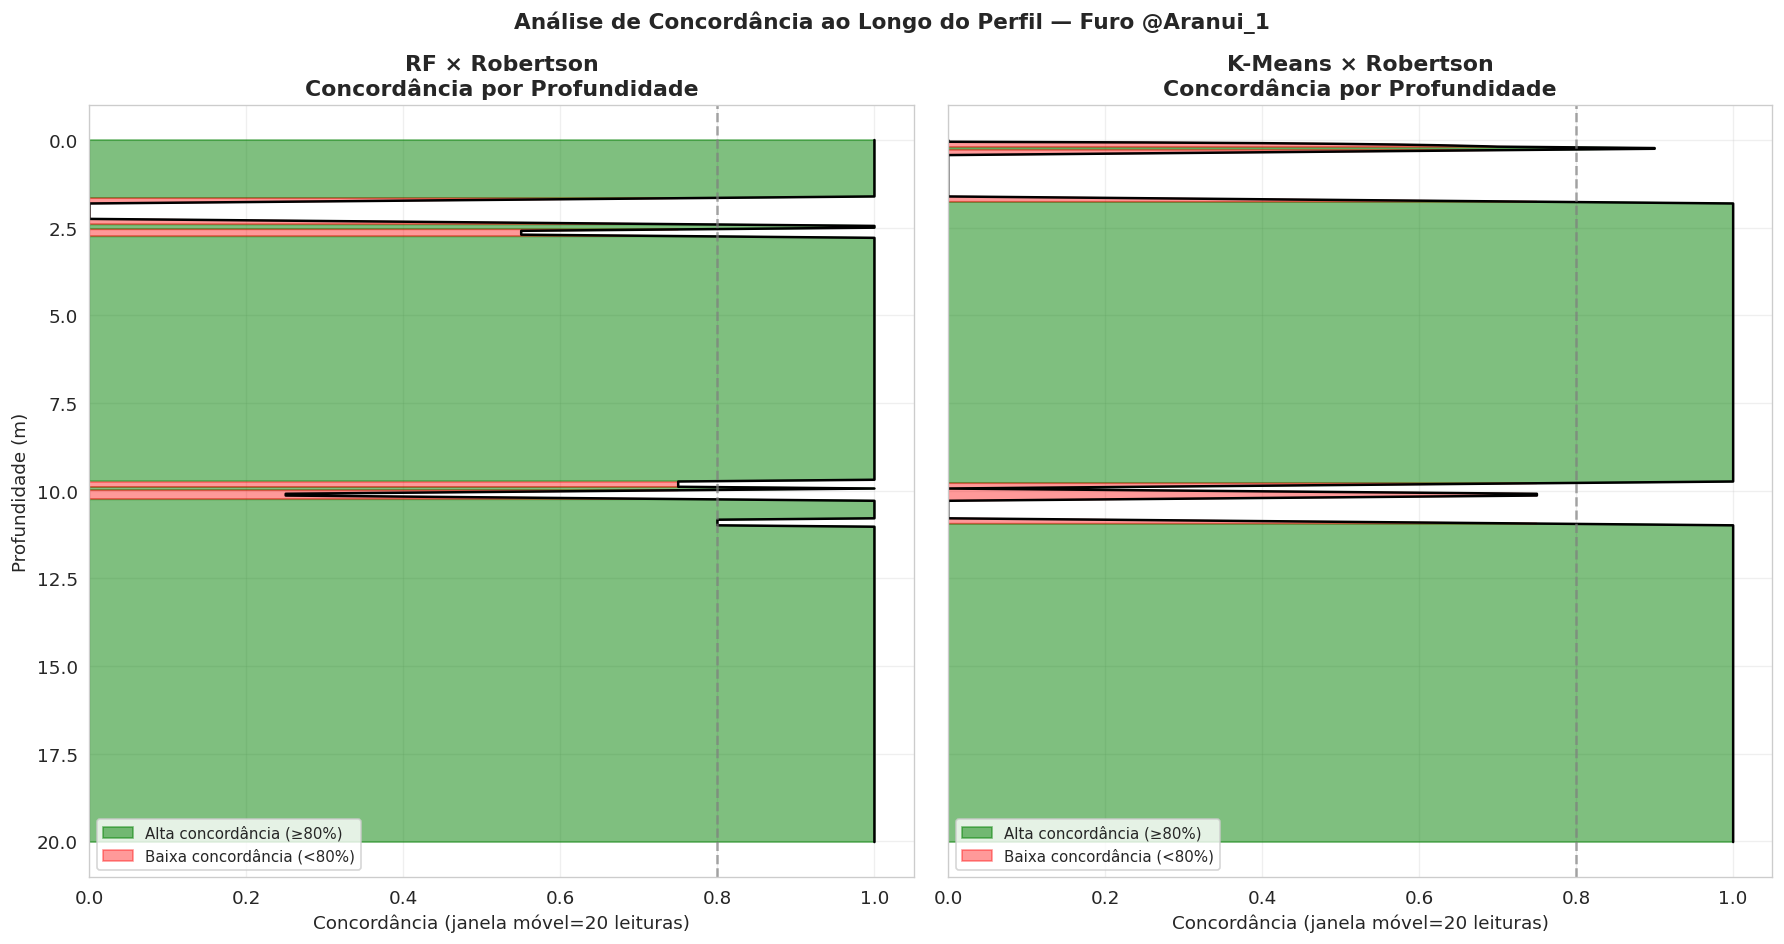


📊 Concordância global no Furo @Aranui_1:
   RF × Robertson  : 95.2%
   K-Means × Robertson : 88.3%
   RF × K-Means    : 83.5%


In [89]:

df_bh_sel = df_model[df_model['borehole_id'] == selected_bh].copy()
df_bh_sel = df_bh_sel.sort_values('depth')
depth_bh  = df_bh_sel['depth'].values

# Predições para o furo selecionado
rob_bh  = df_bh_sel['zone_robertson'].values
rf_bh   = pipeline_rf.predict(df_bh_sel[FEATURES_RF].values)
km_raw  = kmeans.predict(scaler_km.transform(df_bh_sel[FEATURES_KMEANS].values))
km_bh   = np.array([map_hungarian.get(l, -1) for l in km_raw])

# Concordâncias por leitura
agree_rf_rob = (rf_bh == rob_bh)
agree_km_rob = (km_bh == rob_bh)
agree_rf_km  = (rf_bh == km_bh)

# Concordância acumulada ao longo da profundidade
window = 20
roll_rf_rob = pd.Series(agree_rf_rob.astype(int)).rolling(window, min_periods=1).mean().values
roll_km_rob = pd.Series(agree_km_rob.astype(int)).rolling(window, min_periods=1).mean().values

fig, axes = plt.subplots(1, 2, figsize=(15, 8), sharey=True)

# Painel 1: concordância RF vs Robertson por profundidade
axes[0].fill_betweenx(depth_bh, 0, roll_rf_rob,
                       where=(roll_rf_rob >= 0.8),
                       color='green', alpha=0.5, label='Alta concordância (≥80%)')
axes[0].fill_betweenx(depth_bh, 0, roll_rf_rob,
                       where=(roll_rf_rob < 0.8),
                       color='red', alpha=0.4, label='Baixa concordância (<80%)')
axes[0].plot(roll_rf_rob, depth_bh, 'k-', linewidth=1.5)
axes[0].axvline(x=0.8, color='gray', linestyle='--', alpha=0.7)
axes[0].set_xlabel(f'Concordância (janela móvel={window} leituras)')
axes[0].set_ylabel('Profundidade (m)')
axes[0].set_title('RF × Robertson\nConcordância por Profundidade', fontweight='bold')
axes[0].set_xlim(0, 1.05)
axes[0].invert_yaxis()
axes[0].legend(loc='lower left', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Painel 2: concordância K-Means vs Robertson
axes[1].fill_betweenx(depth_bh, 0, roll_km_rob,
                       where=(roll_km_rob >= 0.8),
                       color='green', alpha=0.5, label='Alta concordância (≥80%)')
axes[1].fill_betweenx(depth_bh, 0, roll_km_rob,
                       where=(roll_km_rob < 0.8),
                       color='red', alpha=0.4, label='Baixa concordância (<80%)')
axes[1].plot(roll_km_rob, depth_bh, 'k-', linewidth=1.5)
axes[1].axvline(x=0.8, color='gray', linestyle='--', alpha=0.7)
axes[1].set_xlabel(f'Concordância (janela móvel={window} leituras)')
axes[1].set_title('K-Means × Robertson\nConcordância por Profundidade', fontweight='bold')
axes[1].set_xlim(0, 1.05)
axes[1].legend(loc='lower left', fontsize=9)
axes[1].grid(True, alpha=0.3)

fig.suptitle(f'Análise de Concordância ao Longo do Perfil — Furo {selected_bh}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Resumo numérico
print(f"\n📊 Concordância global no Furo {selected_bh}:")
print(f"   RF × Robertson  : {agree_rf_rob.mean():.1%}")
print(f"   K-Means × Robertson : {agree_km_rob.mean():.1%}")
print(f"   RF × K-Means    : {agree_rf_km.mean():.1%}")



# ║  CÉLULA 23 — ESPAÇO Qt × Fr COM ZONAS DE ROBERTSON      ║


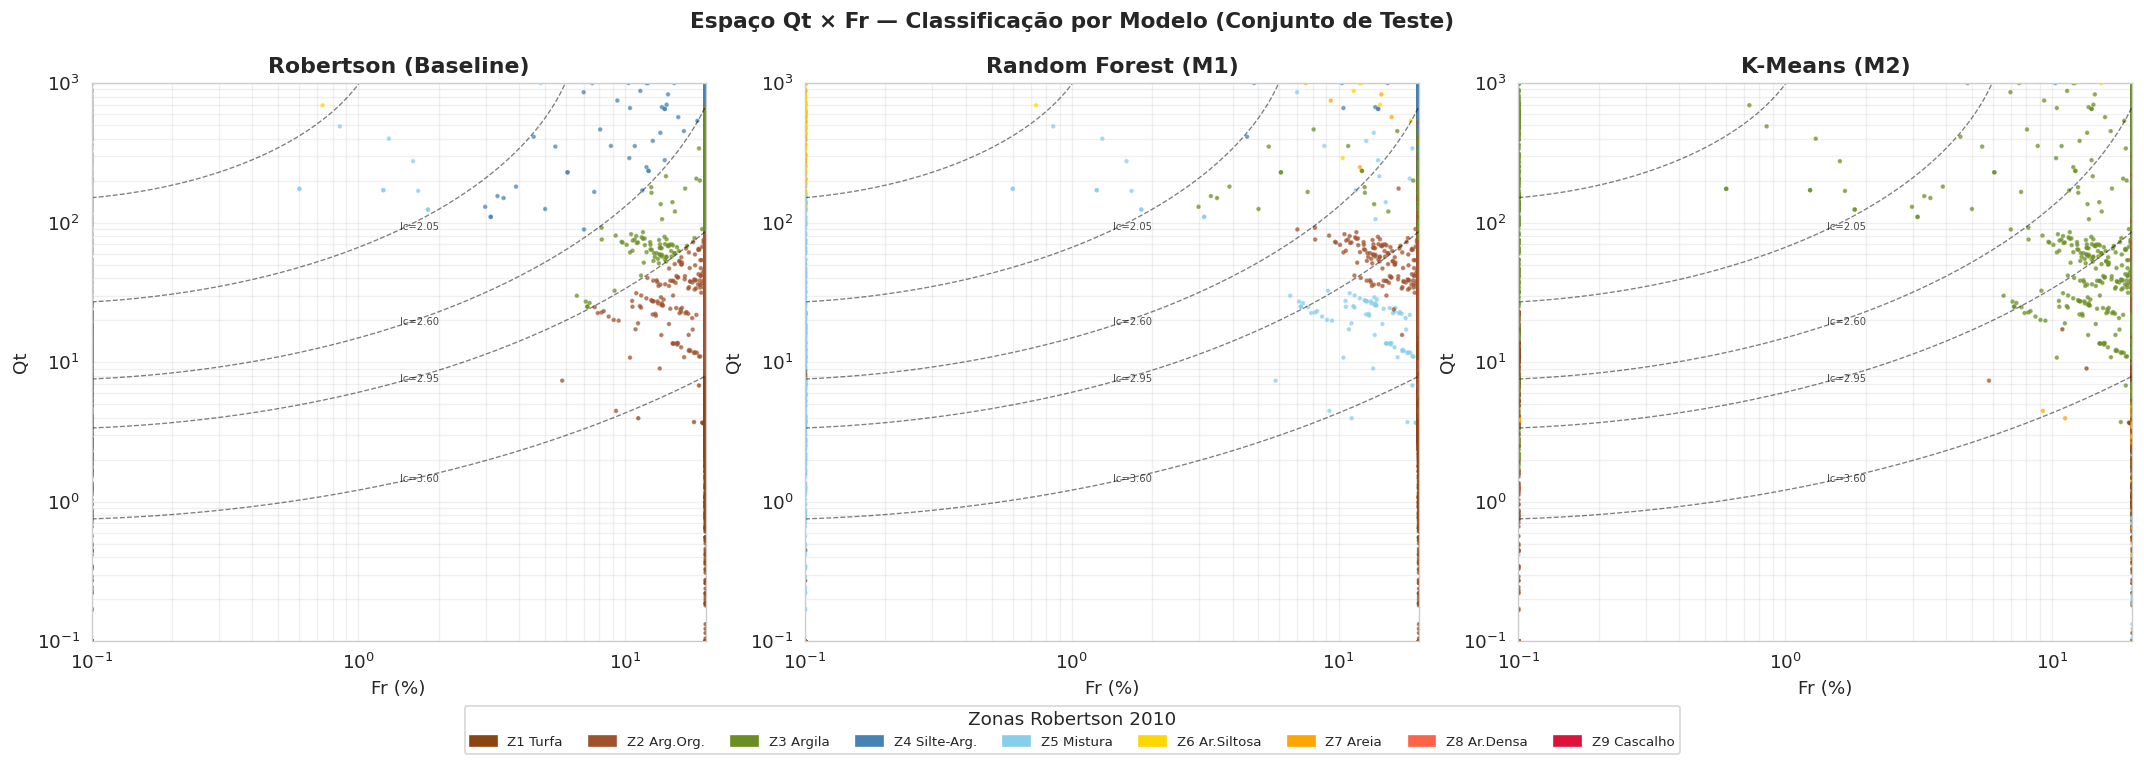

In [90]:

# Visualizar no espaço de Robertson onde cada modelo prediz cada classe
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

df_plot = df_model.iloc[test_idx].copy()
df_plot['pred_rf'] = y_pred_rf
df_plot['pred_km'] = y_pred_km

Qt_clip = np.clip(df_plot['Qt'], 0.1, 1000)
Fr_clip = np.clip(df_plot['Fr'], 0.1, 20)

for ax, (col, title) in zip(axes, [
    ('zone_robertson', 'Robertson (Baseline)'),
    ('pred_rf',        'Random Forest (M1)'),
    ('pred_km',        'K-Means (M2)'),
]):
    zones = df_plot[col].values
    colors = [ZONE_COLORS.get(z, '#CCCCCC') for z in zones]
    ax.scatter(Fr_clip, Qt_clip, c=colors, s=3, alpha=0.6)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Fr (%)')
    ax.set_ylabel('Qt')
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(0.1, 20)
    ax.set_ylim(0.1, 1000)
    ax.grid(True, alpha=0.3, which='both')

    # Linhas de referência Ic
    for Ic_line, label in [(1.31, 'Ic=1.31'), (2.05, 'Ic=2.05'),
                            (2.60, 'Ic=2.60'), (2.95, 'Ic=2.95'), (3.60, 'Ic=3.60')]:
        Fr_arr = np.logspace(-1, 1.3, 200)
        # Qt a partir de Ic: (3.47 - log Qt)² + (log Fr + 1.22)² = Ic²
        # → log Qt = 3.47 - sqrt(Ic² - (log Fr + 1.22)²)  [quando possível]
        disc = Ic_line**2 - (np.log10(Fr_arr) + 1.22)**2
        valid = disc >= 0
        Qt_arr = np.where(valid, 10**(3.47 - np.sqrt(np.where(valid, disc, 0))), np.nan)
        ax.plot(Fr_arr, Qt_arr, 'k--', linewidth=0.8, alpha=0.5)
        idx_mid = len(Fr_arr)//2
        if not np.isnan(Qt_arr[idx_mid]):
            ax.text(Fr_arr[idx_mid], Qt_arr[idx_mid], label,
                    fontsize=6, color='black', alpha=0.7)

# Legenda
legend_patches = [
    mpatches.Patch(color=ZONE_COLORS.get(z, '#CCC'), label=ZONE_LABELS.get(z, f'Z{z}'))
    for z in sorted(ZONE_COLORS.keys())
]
fig.legend(handles=legend_patches, loc='lower center', ncol=9,
           bbox_to_anchor=(0.5, -0.06), fontsize=8,
           title='Zonas Robertson 2010')

plt.suptitle('Espaço Qt × Fr — Classificação por Modelo (Conjunto de Teste)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



# ║  CÉLULA 24 — RESUMO EXECUTIVO FINAL                     ║


In [93]:

print("=" * 65)
print("📋  RESUMO EXECUTIVO — MVP CPT CLASSIFICATION")
print("=" * 65)

print(f"""
DATASET
  Furos totais          : {df_raw['borehole_id'].nunique()}
  Leituras totais       : {df_raw.shape[0]}
  Features (RF)         : {len(FEATURES_RF)} (sem Ic — Robertson-blind)
  Holdout               : Split por furo (sem vazamento espacial)

BASELINE — ROBERTSON (2010)
  Método                : Determinístico via índice Ic
  Accuracy (teste)      : {accuracy_score(y_test, y_robertson):.4f}
  F1-Weighted           : {f1_score(y_test, y_robertson, average='weighted', zero_division=0):.4f}
  Cohen's κ             : {cohen_kappa_score(y_test, y_robertson):.4f}

MODELO 1 — RANDOM FOREST (Supervisionado)
  Accuracy (teste)      : {accuracy_score(y_test, y_pred_rf):.4f}
  F1-Weighted           : {f1_score(y_test, y_pred_rf, average='weighted', zero_division=0):.4f}
  Cohen's κ             : {cohen_kappa_score(y_test, y_pred_rf):.4f}
  Balanceamento         : SMOTE + class_weight='balanced'
  Validação             : GroupKFold (k=5, agrupado por furo)

MODELO 2 — K-MEANS (Não Supervisionado)
  k                     : {n_classes} (comparável com Robertson)
  Mapeamento            : Algoritmo Húngaro (ótimo)
  Accuracy mapeada      : {accuracy_score(y_test, y_pred_km):.4f}
  ARI                   : {adjusted_rand_score(y_test, labels_test_raw):.4f}
  NMI                   : {normalized_mutual_info_score(y_test, labels_test_raw):.4f}
  Silhouette (teste)    : {silhouette_score(X_test_km_scaled, labels_test_raw):.4f}
""")

📋  RESUMO EXECUTIVO — MVP CPT CLASSIFICATION


KeyboardInterrupt: 